D:\Users\Dustin\AppData\Local\Temp\ipykernel_27764\2126912340.py:25: DtypeWarning: Columns (231,232,233,234,235,236,237,238,239) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('epcg23.zip')


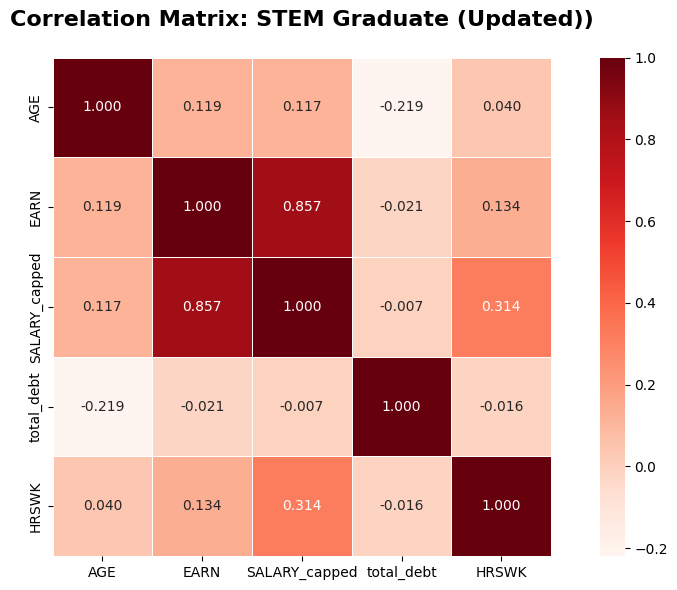

In [2]:
# ============================================
# MILESTONE: This is to combine all the work 
# from the previous weeks into a single notebook.
# The goal is to have a clean, well-documented notebook
# that demonstrates the entire data analysis process,
# from loading and cleaning the data to performing PCA.
#
# I find it very difficult to keep track of all the changes 
# across multiple weeks, so this is an effort to 
# consolidate everything into one place.
# ============================================

# ============================================
# PART 1: DATA LOADING & CLEANING (Week 2)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv('epcg23.zip')
dict_df = pd.read_csv('Dpcg23.csv')

# Remove top-coded earnings
invalid_mask = df['EARN'] >= 9999990
df_clean = df[~invalid_mask].copy()

# Cap at 99th percentile
earnings_99th = df_clean['EARN'].quantile(0.99)
df_clean_99 = df_clean[df_clean['EARN'] <= earnings_99th].copy()


# ============================================
# PART 2: STEM CLASSIFICATION (Week 4 and 6)
# ============================================

# Load field mapping
majors_df = pd.read_csv('N2BAMED.csv')

# STEM keywords
stem_keywords = [
    'computer', 'information', 'engineering', 'mathematics', 'statistics',
    'physics', 'chemistry', 'biology', 'biochemistry', 'neuroscience',
    'astronomy', 'geology', 'environmental science', 'materials science',
    'applied mathematics', 'operations research', 'data science', 'science',
    'technology', 'mechanical', 'electrical', 'civil', 'chemical', 'aerospace'
]

def is_stem_field(desc):
    if pd.isna(desc):
        return 0
    desc_lower = str(desc).lower()
    for keyword in stem_keywords:
        if keyword in desc_lower:
            return 1
    return 0

# Apply STEM classification
majors_df['is_stem'] = majors_df['Description'].apply(is_stem_field)
major_to_stem = dict(zip(majors_df['Value'], majors_df['is_stem']))

df_final = df_clean_99.copy()
df_final['is_stem_major'] = df_final['N2BAMED'].map(major_to_stem).fillna(0)

# ===== DEBT MAPPING (from Ppcg23.pdf) =====
ugloanr_mapping = {
    1: 0,        # Did not earn degree
    2: 0,        # $0 debt
    3: 5000,     # 1-10k
    4: 15000,    # 10-20k
    5: 25000,    # 20-30k
    6: 35000,    # 30-40k
    7: 45000,    # 40-50k
    8: 55000,    # 50-60k
    9: 65000,    # 60-70k
    10: 75000,   # 70-80k
    11: 85000,   # 80-90k
    12: 100000   # 90k or more
}

# Apply mapping to create dollar amounts
df_final['UGLOANR_amount'] = df_final['UGLOANR'].map(ugloanr_mapping).fillna(0)

# Handle GRLOANR if it exists
if 'GRLOANR' in df_final.columns:
    df_final['GRLOANR_amount'] = df_final['GRLOANR'].map(ugloanr_mapping).fillna(0)
else:
    df_final['GRLOANR_amount'] = 0

# Calculate total debt in dollars
df_final['total_debt'] = df_final['UGLOANR_amount'] + df_final['GRLOANR_amount']

# ===== HIGH DEBT + LOW INCOME ANALYSIS =====
income_col = 'SALARY' if 'SALARY' in df_final.columns else 'EARN'

high_debt_condition = df_final['UGLOANR'] == 12
low_income_condition = df_final[income_col] < 100000

high_debt_low_income = df_final[high_debt_condition & low_income_condition].copy()
stem_high_debt_low_income = high_debt_low_income[high_debt_low_income['is_stem_major'] == 1]
nonstem_high_debt_low_income = high_debt_low_income[high_debt_low_income['is_stem_major'] == 0]


# ============================================
# PART 3: RECENT GRADUATES & WORKING IN STEM (Week 6)
# ============================================

# Filter to recent graduates (last 10 years)
recent_year = df_final['BAYR'].max() - 10
df_recent = df_final[df_final['BAYR'] >= recent_year].copy()

# Determine if working in STEM (OCEDRLP: 1=closely, 2=somewhat)
df_recent['working_in_stem_field'] = df_recent['OCEDRLP'].isin([1, 2])

# Create cohorts
df_recent['cohort'] = pd.cut(
    df_recent['BAYR'],
    bins=[2013, 2015, 2017, 2019, 2021, 2023],
    labels=['2013-15', '2015-17', '2017-19', '2019-21', '2021-23']
)

# Clean SALARY (same as EARN)
invalid_salary = df_recent['SALARY'] >= 9999990
df_recent['SALARY_clean'] = df_recent['SALARY'].copy()
df_recent.loc[invalid_salary, 'SALARY_clean'] = np.nan
salary_99th = df_recent['SALARY_clean'].quantile(0.99)
df_recent['SALARY_capped'] = df_recent['SALARY_clean'].clip(upper=salary_99th)


# ============================================
# PART 4: PCA ANALYSIS - CORRELATION & PCA (Week 9)
# ============================================

# Update numeric columns with cleaned SALARY
numeric_cols = ['AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK']
available_cols = [col for col in numeric_cols if col in df_recent.columns]

# Correlation matrix with cleaned SALARY
corr_matrix = df_recent[available_cols].corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Reds', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: STEM Graduate (Updated))\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Select numeric features for PCA
pca_features = ['AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK']

# Make sure all features exist
available_features = [f for f in pca_features if f in df_recent.columns]

# Drop rows with missing values
pca_data = df_recent[available_features].dropna()

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# ============================================
# SAVE CLEANED DATA FOR FUTURE USE
# ============================================

df_clean_99.to_csv('df_clean_99.csv.zip', index=False, compression='zip')
df_final.to_csv('df_final.csv.zip', index=False, compression='zip')
df_recent.to_csv('df_recent.csv.zip', index=False, compression='zip')
